# FIFA World Cup 2026 Simulator

This section of the project simulates one random timeline of the World Cup based on the model's odds. It generates specific match scores, cards, and realistic schedules so you can see a single, unique way the tournament could play out.

In [1]:
from IPython.display import Markdown

from wcmodel.team_data import *
from wcmodel.match import *
from wcmodel.tournament import *
from wcmodel.charts import *

wc_team_stats = build_all_team_data()
match_sim = MatchSimulator(wc_team_stats)
tournament_sim = TournamentSimulator(match_sim, group_fixtures, knockout_slots)

### Group Stage Results

In [2]:
group_predictions = tournament_sim.group_results(group_fixtures.copy())

display(style_table(group_predictions.set_index('match_id'), percent = False))

,group,home_team,away_team,date_utc,venue,predicted_home_goals,predicted_away_goals,home_yellow_cards,home_red_cards,away_yellow_cards,away_red_cards,winning_team
1,A,Mexico,South Africa,2026-06-11T19:00:00Z,"Estadio Azteca, Mexico City",1,0,1,0,3,0,Mexico
2,A,South Korea,Czech Republic,2026-06-12T02:00:00Z,"Estadio Akron, Guadalajara",2,1,1,0,2,0,South Korea
3,B,Canada,Bosnia and Herzegovina,2026-06-12T19:00:00Z,"BMO Field, Toronto",2,1,2,0,1,0,Canada
4,D,USA,Paraguay,2026-06-13T01:00:00Z,"SoFi Stadium, Los Angeles",3,1,3,0,3,0,USA
5,D,Australia,Turkey,2026-06-13T04:00:00Z,"BC Place, Vancouver",3,0,6,0,0,0,Australia
6,B,Qatar,Switzerland,2026-06-13T19:00:00Z,"Levi's Stadium, Santa Clara",2,5,0,0,3,0,Switzerland
7,C,Brazil,Morocco,2026-06-13T22:00:00Z,"MetLife Stadium, East Rutherford",1,0,3,0,3,0,Brazil
8,C,Haiti,Scotland,2026-06-14T01:00:00Z,"Gillette Stadium, Boston",0,2,0,0,2,1,Scotland
9,E,Germany,Curaçao,2026-06-14T17:00:00Z,"NRG Stadium, Houston",6,1,3,0,1,0,Germany
10,F,Netherlands,Japan,2026-06-14T20:00:00Z,"AT&T Stadium, Dallas",0,2,0,0,1,0,Japan


### Group Stage Table

#### Group Stage Tiebreaker Order

1. Head-to-Head Points: Total points obtained in the matches played strictly between the tied teams.

2. Head-to-Head Goal Difference: Goal difference resulting only from matches played between the tied teams.

3. Head-to-Head Goals Scored: Total goals scored strictly in matches between the tied teams.

4. Overall Goal Difference: Total goal difference across all group stage matches (GD column).

5. Overall Goals Scored: Total goals scored across all group stage matches (GF column).

6. Team Conduct Score: The highest fair play score calculated from accumulated yellow and red cards (TCS column).

7. FIFA World Ranking: The team with the higher official global rank immediately entering the tournament.

In [3]:
standings = tournament_sim.group_standings(group_predictions)

display(style_table(standings.drop(columns = ['h2h', 'rank']), group_size = 4, percent = False))

,Pts,GD,GF,GA,TCS,group
South Korea,9,4,5,1,-4,A
Czech Republic,4,1,6,5,-3,A
Mexico,3,-2,3,5,-7,A
South Africa,1,-3,1,4,-5,A
Switzerland,9,9,12,3,-3,B
Canada,6,0,4,4,-5,B
Bosnia and Herzegovina,3,-4,3,7,-5,B
Qatar,0,-5,3,8,-3,B
Scotland,6,2,4,2,-6,C
Brazil,6,4,7,3,-7,C


### Qualified Thirds Table

The top 8 third-place teams qualify for the knockout stage.

In [4]:
display(style_table(tournament_sim.qualified_thirds.drop(columns = ['h2h']), percent = False))

,Pts,GD,GF,GA,TCS,rank,group
Côte d'Ivoire,4,0,3,3,-2,33,E
Morocco,4,0,1,1,-4,7,C
Iraq,4,-2,3,5,-8,57,I
Iran,3,0,5,5,-6,20,G
Austria,3,0,2,2,-7,24,J
Paraguay,3,-2,4,6,-4,41,D
Mexico,3,-2,3,5,-7,14,A
Spain,3,-2,3,5,-10,2,H


### Knockout Stage Results

Games that are level after 90 minutes go to extra time. If the teams are still tied after 120 minutes, the game goes to penalties, which is decided in this simulation by a coin flip.

In [5]:
knockout_predictions = tournament_sim.run_knockout_stages(knockout_slots.copy())

for round_name in knockout_predictions['round'].unique():
    display(Markdown(f'**{round_name}**'))
    display(style_table(knockout_predictions[knockout_predictions['round'] == round_name].drop(columns = 'round').set_index('match_id'), percent = False))

**Round of 32**

,date_utc,venue,slot_home,slot_away,predicted_home_team,predicted_away_team,predicted_home_goals,predicted_away_goals,home_yellow_cards,home_red_cards,away_yellow_cards,away_red_cards,winning_team,extra_time,penalties
73,2026-06-28T19:00:00Z,"SoFi Stadium, Los Angeles",Runner-up Group A,Runner-up Group B,Czech Republic,Canada,1,0,0,0,4,0,Czech Republic,False,False
74,2026-06-29T20:30:00Z,"Gillette Stadium, Boston",Winner Group E,Best 3rd (Groups A/B/C/D/F),Germany,Morocco,3,1,0,0,2,0,Germany,False,False
75,2026-06-30T01:00:00Z,"Estadio BBVA, Monterrey",Winner Group F,Runner-up Group C,Japan,Brazil,2,0,0,0,2,0,Japan,False,False
76,2026-06-29T17:00:00Z,"NRG Stadium, Houston",Winner Group C,Runner-up Group F,Scotland,Netherlands,0,3,3,0,1,0,Netherlands,False,False
77,2026-06-30T21:00:00Z,"MetLife Stadium, East Rutherford",Winner Group I,Best 3rd (Groups C/D/F/G/H),Norway,Paraguay,0,0,2,0,0,0,Norway,True,True
78,2026-06-30T17:00:00Z,"AT&T Stadium, Dallas",Runner-up Group E,Runner-up Group I,Ecuador,France,1,1,2,1,2,0,France,True,True
79,2026-07-01T01:00:00Z,"Estadio Azteca, Mexico City",Winner Group A,Best 3rd (Groups C/E/F/H/I),South Korea,Spain,0,7,3,0,2,1,Spain,False,False
80,2026-07-01T16:00:00Z,"Mercedes-Benz Stadium, Atlanta",Winner Group L,Best 3rd (Groups E/H/I/J/K),Croatia,Iraq,4,0,1,0,1,0,Croatia,False,False
81,2026-07-02T00:00:00Z,"Levi's Stadium, Santa Clara",Winner Group D,Best 3rd (Groups B/E/F/I/J),USA,Austria,0,1,1,0,1,0,Austria,False,False
82,2026-07-01T20:00:00Z,"Lumen Field, Seattle",Winner Group G,Best 3rd (Groups A/E/H/I/J),Belgium,Mexico,1,0,1,0,2,1,Belgium,False,False


**Round of 16**

,date_utc,venue,slot_home,slot_away,predicted_home_team,predicted_away_team,predicted_home_goals,predicted_away_goals,home_yellow_cards,home_red_cards,away_yellow_cards,away_red_cards,winning_team,extra_time,penalties
89,2026-07-04T21:00:00Z,"Lincoln Financial Field, Philadelphia",Winner Match 74,Winner Match 77,Germany,Norway,1,2,3,0,3,0,Norway,False,False
90,2026-07-04T17:00:00Z,"NRG Stadium, Houston",Winner Match 73,Winner Match 75,Czech Republic,Japan,1,2,1,1,2,0,Japan,False,False
91,2026-07-05T20:00:00Z,"MetLife Stadium, East Rutherford",Winner Match 76,Winner Match 78,Netherlands,France,3,2,0,0,4,0,Netherlands,False,False
92,2026-07-06T00:00:00Z,"Estadio Azteca, Mexico City",Winner Match 79,Winner Match 80,Spain,Croatia,1,0,1,0,3,0,Spain,False,False
93,2026-07-06T19:00:00Z,"AT&T Stadium, Dallas",Winner Match 83,Winner Match 84,England,Uruguay,2,2,3,0,4,0,England,True,True
94,2026-07-07T00:00:00Z,"Lumen Field, Seattle",Winner Match 81,Winner Match 82,Austria,Belgium,1,2,3,0,2,0,Belgium,False,False
95,2026-07-07T16:00:00Z,"Mercedes-Benz Stadium, Atlanta",Winner Match 86,Winner Match 88,Argentina,Egypt,2,0,3,0,1,1,Argentina,False,False
96,2026-07-07T20:00:00Z,"BC Place, Vancouver",Winner Match 85,Winner Match 87,Switzerland,Portugal,0,2,6,0,6,0,Portugal,True,False


**Quarter-final**

...

,date_utc,venue,slot_home,slot_away,predicted_home_team,predicted_away_team,predicted_home_goals,predicted_away_goals,home_yellow_cards,home_red_cards,away_yellow_cards,away_red_cards,winning_team,extra_time,penalties
101,2026-07-14T19:00:00Z,"AT&T Stadium, Dallas",Winner Match 97,Winner Match 98,Japan,England,1,2,2,1,1,0,England,False,False
102,2026-07-15T19:00:00Z,"Mercedes-Benz Stadium, Atlanta",Winner Match 99,Winner Match 100,Spain,Portugal,1,2,2,0,0,0,Portugal,False,False


**Third-place playoff**

,date_utc,venue,slot_home,slot_away,predicted_home_team,predicted_away_team,predicted_home_goals,predicted_away_goals,home_yellow_cards,home_red_cards,away_yellow_cards,away_red_cards,winning_team,extra_time,penalties
103,2026-07-18T21:00:00Z,"Hard Rock Stadium, Miami",Loser Match 101,Loser Match 102,Japan,Spain,0,1,0,0,5,0,Spain,False,False


**Final**

,date_utc,venue,slot_home,slot_away,predicted_home_team,predicted_away_team,predicted_home_goals,predicted_away_goals,home_yellow_cards,home_red_cards,away_yellow_cards,away_red_cards,winning_team,extra_time,penalties
104,2026-07-19T19:00:00Z,"MetLife Stadium, East Rutherford",Winner Match 101,Winner Match 102,England,Portugal,3,0,3,0,1,0,England,True,False


### 🏆 Knockout Bracket

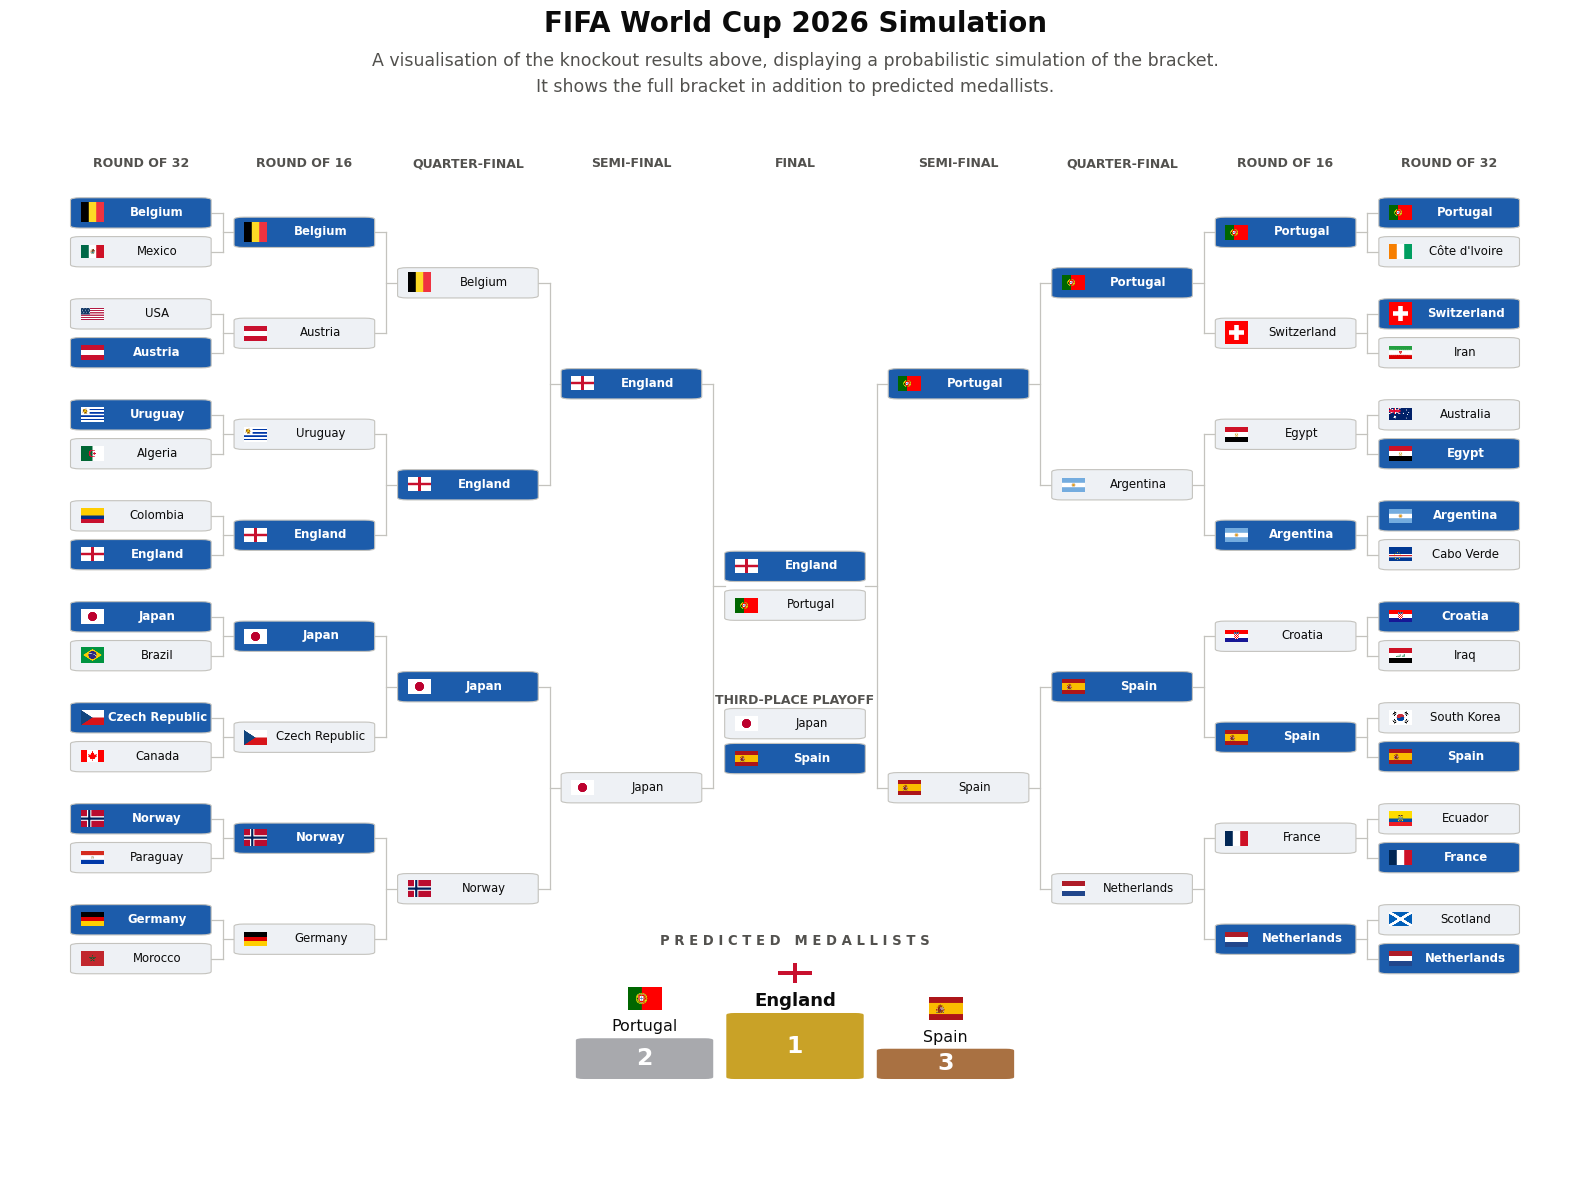

In [6]:
prepared_bracket = knockout_predictions.rename(columns={
    'round': 'Round',
    'predicted_home_team': 'Home',
    'predicted_away_team': 'Away',
    'winning_team': 'Winner'
}).set_index('match_id')

sim_bracket = plot_bracket(prepared_bracket, knockout_slots, title_odds = None, save = False,
    title = 'FIFA World Cup 2026 Simulation',
    subtitle = 'A visualisation of the knockout results above, displaying a probabilistic simulation of the bracket.'
    '\nIt shows the full bracket in addition to predicted medallists.')